In [1]:
# Running locally - data loaded directly from Datasets folder.
# If running on Colab, you can upload the dataset or mount Google Drive.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
import os
# Path to dataset relative to IPYNB directory
DATASET_PATH = os.path.join("..", "Datasets", "asthma_disease_data.csv")
df = pd.read_csv(DATASET_PATH)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (2392, 29)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid


In [4]:
print("Dataset Info:")
print(df.info())

print("\nNull Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns.tolist())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2392 non-null   int64  
 1   Age                     2392 non-null   int64  
 2   Gender                  2392 non-null   int64  
 3   Ethnicity               2392 non-null   int64  
 4   EducationLevel          2392 non-null   int64  
 5   BMI                     2392 non-null   float64
 6   Smoking                 2392 non-null   int64  
 7   PhysicalActivity        2392 non-null   float64
 8   DietQuality             2392 non-null   float64
 9   SleepQuality            2392 non-null   float64
 10  PollutionExposure       2392 non-null   float64
 11  PollenExposure          2392 non-null   float64
 12  DustExposure            2392 non-null   float64
 13  PetAllergy              2392 non-null   int64  
 14  FamilyHistoryAsthma     23

In [5]:
print("Diagnosis Value Counts:")
print(df["Diagnosis"].value_counts())

print("\nDiagnosis Percentage:")
print(df["Diagnosis"].value_counts(normalize=True) * 100)

Diagnosis Value Counts:
Diagnosis
0    2268
1     124
Name: count, dtype: int64

Diagnosis Percentage:
Diagnosis
0    94.816054
1     5.183946
Name: proportion, dtype: float64


In [6]:
features = [
    "Age",
    "Gender",
    "BMI",
    "Smoking",
    "HistoryOfAllergies",
    "FamilyHistoryAsthma",
    "Eczema",
    "HayFever",
    "LungFunctionFEV1",
    "LungFunctionFVC",
    "Wheezing",
    "ShortnessOfBreath",
    "ChestTightness",
    "Coughing",
    "NighttimeSymptoms",
    "ExerciseInduced"
]

target = "Diagnosis"

X = df[features]
y = df[target]

print("Selected Features:")
print(X.columns.tolist())

print("\nTarget:", target)

Selected Features:
['Age', 'Gender', 'BMI', 'Smoking', 'HistoryOfAllergies', 'FamilyHistoryAsthma', 'Eczema', 'HayFever', 'LungFunctionFEV1', 'LungFunctionFVC', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced']

Target: Diagnosis


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())

X_train shape: (1913, 16)
X_test shape: (479, 16)
y_train distribution:
Diagnosis
0    1814
1      99
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


Training Logistic Regression...
Accuracy : 0.5386
Precision: 0.9102
Recall   : 0.5386
F1 Score : 0.6582

Training Random Forest...


Accuracy : 0.9478
Precision: 0.8983
Recall   : 0.9478
F1 Score : 0.9224

Training XGBoost...
Accuracy : 0.9478
Precision: 0.8983
Recall   : 0.9478
F1 Score : 0.9224


C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="F1 Score", ascending=False)

display(results_df)

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.947808,0.898340,0.947808,0.922411
XGBoost,0.947808,0.898340,0.947808,0.922411
Logistic Regression,0.538622,0.910184,0.538622,0.658239


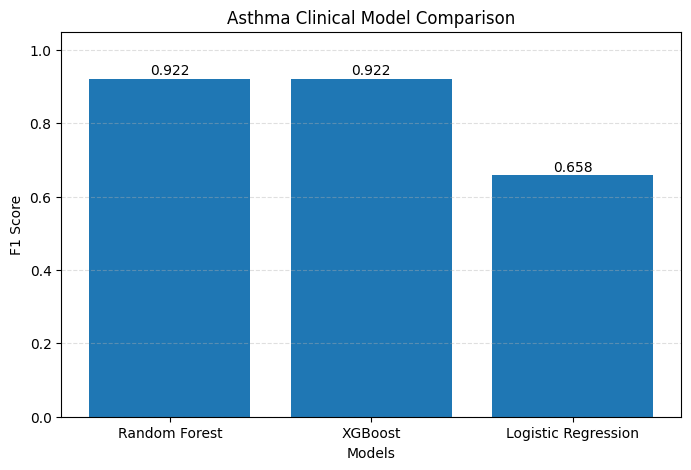

In [11]:
plt.figure(figsize=(8,5))

plt.bar(results_df.index, results_df["F1 Score"])

plt.title("Asthma Clinical Model Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)

for i, v in enumerate(results_df["F1 Score"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [12]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print("="*60)
print("BEST ASTHMA CLINICAL MODEL:", best_model_name)
print("="*60)

BEST ASTHMA CLINICAL MODEL: Random Forest


              BEST MODEL: Random Forest

Accuracy : 0.9478
Precision: 0.8983
Recall   : 0.9478
F1 Score : 0.9224

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       454
           1       0.00      0.00      0.00        25

    accuracy                           0.95       479
   macro avg       0.47      0.50      0.49       479
weighted avg       0.90      0.95      0.92       479



C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: Unde

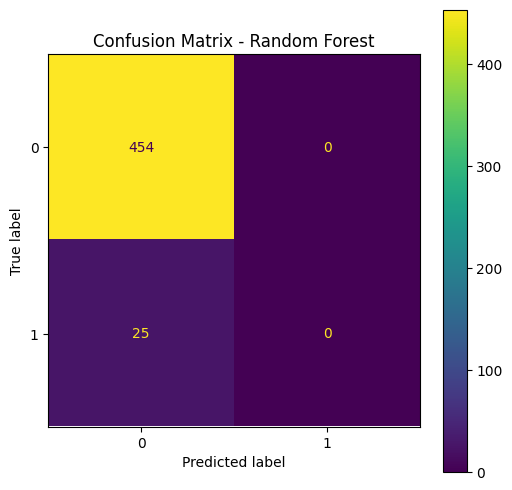

In [13]:
if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average="weighted")
recall = recall_score(y_test, y_pred_best, average="weighted")
f1 = f1_score(y_test, y_pred_best, average="weighted")

print("="*70)
print(f"              BEST MODEL: {best_model_name}")
print("="*70)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False)
plt.show()

,Feature,Importance
2,BMI,0.185086
8,LungFunctionFEV1,0.181647
9,LungFunctionFVC,0.175464
0,Age,0.163482
14,NighttimeSymptoms,0.029286
15,ExerciseInduced,0.027613
13,Coughing,0.026696
12,ChestTightness,0.026016
10,Wheezing,0.025959
4,HistoryOfAllergies,0.025934


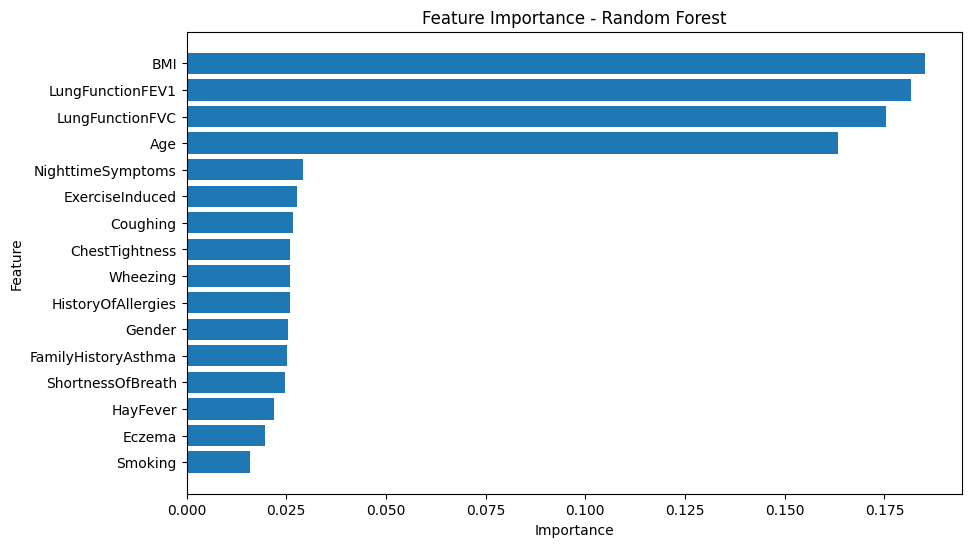

In [14]:
if best_model_name in ["Random Forest", "XGBoost"]:
    importance = best_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    display(feature_importance_df)

    plt.figure(figsize=(10,6))
    plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Feature importance is not directly available for Logistic Regression.")

In [15]:
joblib.dump(best_model, "best_asthma_clinical_model.pkl")
joblib.dump(scaler, "asthma_scaler.pkl")
joblib.dump(features, "asthma_feature_columns.pkl")

print("Files saved successfully:")
print("best_asthma_clinical_model.pkl")
print("asthma_scaler.pkl")
print("asthma_feature_columns.pkl")

Files saved successfully:
best_asthma_clinical_model.pkl
asthma_scaler.pkl
asthma_feature_columns.pkl


In [16]:
try:
    from google.colab import files
    files.download("best_asthma_clinical_model.pkl")
    files.download("asthma_scaler.pkl")
    files.download("asthma_feature_columns.pkl")
except ImportError:
    print("Saved files locally. (Google Colab files.download skipped)")

Saved files locally. (Google Colab files.download skipped)


In [17]:
sample = X_test.iloc[[0]]

print("Sample Input:")
display(sample.T)

print("\nColumn Order:")
print(sample.columns.tolist())

if best_model_name == "Logistic Regression":
    sample_scaled = scaler.transform(sample)
    pred = best_model.predict(sample_scaled)
    prob = best_model.predict_proba(sample_scaled)
else:
    pred = best_model.predict(sample)
    prob = best_model.predict_proba(sample)

print("\nPredicted Asthma Diagnosis:", pred[0])

print("\nPrediction Probabilities:")
for cls, p in zip(best_model.classes_, prob[0]):
    print(f"Class {cls}: {p*100:.2f}%")

Sample Input:


,2068
Age,72.000000
Gender,0.000000
BMI,22.304940
Smoking,0.000000
HistoryOfAllergies,0.000000
FamilyHistoryAsthma,0.000000
Eczema,0.000000
HayFever,0.000000
LungFunctionFEV1,2.634423
LungFunctionFVC,2.749343



Column Order:
['Age', 'Gender', 'BMI', 'Smoking', 'HistoryOfAllergies', 'FamilyHistoryAsthma', 'Eczema', 'HayFever', 'LungFunctionFEV1', 'LungFunctionFVC', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced']

Predicted Asthma Diagnosis: 0

Prediction Probabilities:
Class 0: 98.00%
Class 1: 2.00%
